In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# loading the data in the dataframe

df = pd.read_csv('../data/raw/application_train.csv')

# first look

print("Shape:" , df.shape)

print("Number of columns:" , len(df.columns))

df.head()


Shape: (307511, 122)
Number of columns: 122


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


Target Value Counts:
TARGET
0    282686
1     24825
Name: count, dtype: int64
Target Proportions
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


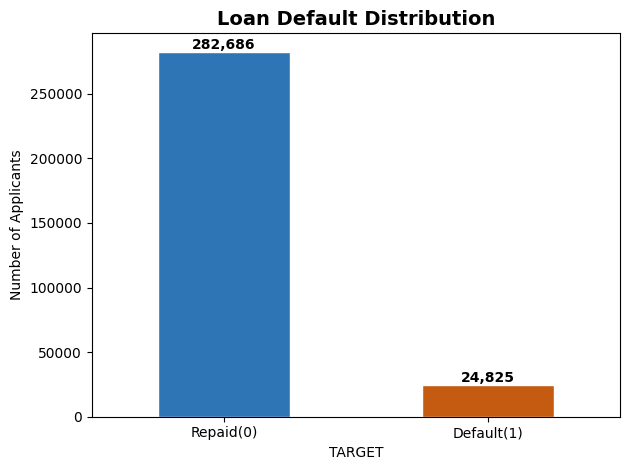

In [2]:

# Counting of values in Target column. Like how many 0s and 1s?
print("Target Value Counts:" )
print(df['TARGET'].value_counts())

# Percentage of counts in Target column
print("Target Proportions")
print(df['TARGET'].value_counts(normalize = True).round(4) * 100)

# visualization

plt.Figure(figsize=(6,4))

ax = df['TARGET'].value_counts().plot(kind='bar', color=['#2E75B6','#C55A11'], edgecolor='white', width=0.5)
plt.title('Loan Default Distribution' , fontsize = 14, fontweight = 'bold')
plt.xticks([0,1] , ['Repaid(0)' , 'Default(1)'] , rotation = 0)
plt.ylabel("Number of Applicants")

for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',(p.get_x() + p.get_width() / 2, p.get_height()), ha = 'center' , va = 'bottom', fontweight = 'bold')
plt.tight_layout()
plt.savefig('../docs/target_distribution.png' , dpi = 150)
plt.show()


In [3]:
# missing value analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

# Show only columns that actually have missing values
missing_df = missing_df[missing_df['Missing Count'] > 0]
print(f'Total columns with missing values:"  {len(missing_df)}')
print(f'Total Columns: {df.shape[1]}')
print(f'\n Top 20 columns by missing % {missing_df.head(20)}')


Total columns with missing values:"  67
Total Columns: 122

 Top 20 columns by missing %                           Missing Count  Missing %
COMMONAREA_AVG                   214865      69.87
COMMONAREA_MODE                  214865      69.87
COMMONAREA_MEDI                  214865      69.87
NONLIVINGAPARTMENTS_MEDI         213514      69.43
NONLIVINGAPARTMENTS_MODE         213514      69.43
NONLIVINGAPARTMENTS_AVG          213514      69.43
FONDKAPREMONT_MODE               210295      68.39
LIVINGAPARTMENTS_AVG             210199      68.35
LIVINGAPARTMENTS_MEDI            210199      68.35
LIVINGAPARTMENTS_MODE            210199      68.35
FLOORSMIN_MODE                   208642      67.85
FLOORSMIN_AVG                    208642      67.85
FLOORSMIN_MEDI                   208642      67.85
YEARS_BUILD_AVG                  204488      66.50
YEARS_BUILD_MODE                 204488      66.50
YEARS_BUILD_MEDI                 204488      66.50
OWN_CAR_AGE                      202929     

In [4]:
# Understanding data types

print("Data Type break down:")

print(df.dtypes.value_counts())

# Displaying numerical / categorical columns

print(f"\n Numerical Columns : {len(df.select_dtypes(include=['int64' , 'float64']).columns)}")


print(f"\n Categorical Columns :{len(df.select_dtypes(include=['object']).columns)}")

Data Type break down:
float64    65
int64      41
object     16
Name: count, dtype: int64

 Numerical Columns : 106

 Categorical Columns :16


In [5]:
# listing columns with Flag

flag_columns = [c for c in df.columns if c.startswith('FLAG')]
print(f"Number of Flag :{len(flag_columns)}")
print("\n Flag column list")
print(flag_columns)

Number of Flag :28

 Flag column list
['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21']


In [6]:
# categorize missingness severity

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame(
{
    'Missing Count' : missing,
    'Missing %' : missing_pct

}).sort_values('Missing %', ascending=False)

missing_df = missing_df[missing_df['Missing Count'] > 0]

missing_df['Severity'] = pd.cut(
    missing_df['Missing %'],
    bins = [-1, 10, 50, 100],
    labels = ['Low (< 10%)' , 'Medium(10-50%)' , 'High(>50%)']
)
print("Severity Breakdown")
print(missing_df['Severity'].value_counts())

print("\n Column with high missingness (>50%)")

print(missing_df[missing_df['Missing %'] > 50].to_string())


Severity Breakdown
Severity
High(>50%)        41
Medium(10-50%)    16
Low (< 10%)       10
Name: count, dtype: int64

 Column with high missingness (>50%)
                          Missing Count  Missing %    Severity
COMMONAREA_AVG                   214865      69.87  High(>50%)
COMMONAREA_MODE                  214865      69.87  High(>50%)
COMMONAREA_MEDI                  214865      69.87  High(>50%)
NONLIVINGAPARTMENTS_MEDI         213514      69.43  High(>50%)
NONLIVINGAPARTMENTS_MODE         213514      69.43  High(>50%)
NONLIVINGAPARTMENTS_AVG          213514      69.43  High(>50%)
FONDKAPREMONT_MODE               210295      68.39  High(>50%)
LIVINGAPARTMENTS_AVG             210199      68.35  High(>50%)
LIVINGAPARTMENTS_MEDI            210199      68.35  High(>50%)
LIVINGAPARTMENTS_MODE            210199      68.35  High(>50%)
FLOORSMIN_MODE                   208642      67.85  High(>50%)
FLOORSMIN_AVG                    208642      67.85  High(>50%)
FLOORSMIN_MEDI            

In [7]:
# Does missingness differ between defaulter and repayers?

df['TOTAL_MISSING_COUNTS'] = df.isnull().sum(axis = 1)

print("=== Average MISSING FIELDS PER APPLICANTS ===")
comparison = df.groupby('TARGET')['TOTAL_MISSING_COUNTS'].agg(['mean' , 'median' , 'max'])
comparison.index = ['Repaid(0)' , 'Defaulted (1)']

print(comparison.round(2))

print("\n=== Difference ===")

diff = (comparison.loc['Defaulted (1)', 'mean'] - comparison.loc['Repaid(0)', 'mean']).round(2)

print(f"Defaulters have average {diff} more missing fields than repayers.")

=== Average MISSING FIELDS PER APPLICANTS ===
               mean  median  max
Repaid(0)      29.5    34.0   61
Defaulted (1)  32.8    48.0   60

=== Difference ===
Defaulters have average 3.3 more missing fields than repayers.


In [8]:
# saving missingness in the document

missing_df['Handling Strategy'] = missing_df['Severity'].map(
    {
    'Low (<10%)' : 'Impute - median / mode',
    'Medium (10 - 50 %)' : 'Impute + IS_MISSING flag',
    'High (>50%)' : 'IS_MISSING flag + review individually'
    }
)

missing_df.to_csv('../docs/missingness_strategy.csv')

print("Missingness strategy saved to docs/missingness_strategy.csv")
print(f"\nSummary:")

print(f" Low - {(missing_df['Severity'] == 'Low (<10%)').sum()} columns - impute directly")
print(f" Low - {(missing_df['Severity'] == 'Medium (10 - 50 %)').sum()} columns - impute + flag")
print(f" Low - {(missing_df['Severity'] == 'High (>50%)').sum()} columns - flat + individual review")
print(f"\nTOTAL_MISSING_COUNT feature retained — avg gap of 3.3 fields confirms predictive value")


Missingness strategy saved to docs/missingness_strategy.csv

Summary:
 Low - 0 columns - impute directly
 Low - 0 columns - impute + flag
 Low - 0 columns - flat + individual review

TOTAL_MISSING_COUNT feature retained — avg gap of 3.3 fields confirms predictive value
